# Раздел 2. Генерация и предварительная обработка данных
**Тема:** Влияние хронического недосыпа на производительность труда

## 2.1. Визуализация причинных связей

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import t, expon, logistic, norm, uniform, chi2
from scipy.stats import gamma as gamma_dist
import matplotlib.pyplot as plt
import seaborn
import networkx as nx
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import bnlearn as bn
import doubleml as dml


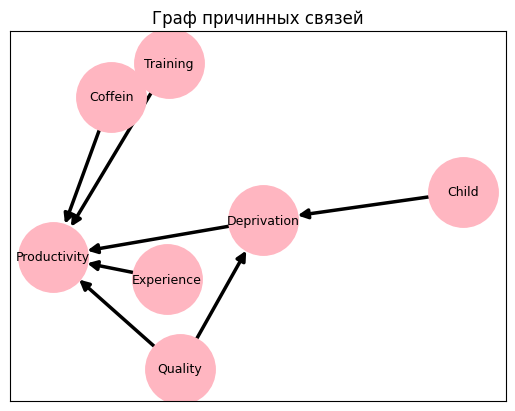

In [4]:
# Визуализируем предполагаемый граф связей
nx_options = {
    'node_color': 'lightpink',
    'node_size': 2500,
    'width': 2.5,
    'arrowstyle': '-|>',
    'arrowsize': 14,
    'font_size': 9,
}

edges = [
    ('Child',      'Deprivation'),
    ('Quality',    'Deprivation'),
    ('Quality',    'Productivity'),
    ('Deprivation','Productivity'),
    ('Experience', 'Productivity'),
    ('Coffein',       'Productivity'),
    ('Training',   'Productivity')
]

G = nx.DiGraph(directed=True)
G.add_edges_from(edges)

np.random.seed(8)
nx.draw_networkx(G, arrows=True, **nx_options)
plt.title('Граф причинных связей')
plt.show()

## 2.2. Генерация экзогенных переменных

Все экзогенные переменные генерируются **независимо** друг от друга.
Параметры калиброваны приблизительно по российским данным.

In [5]:
# Для воспроизводимости
np.random.seed(123)

# Число наблюдений
n = 10000

### Стаж (непрерывная, годы)

In [6]:
# Стаж работы. реальные данные: среднее 12.4, ст.отклонение 50
# Среднее ≈ 10 лет, что близко к среднему стажу в РФ
experience = gamma_dist.rvs(a=2, scale=5, size=n)

# Ограничим значения реалистичным диапазоном
experience[experience > 50] = 50
experience[experience < 0.5] = 0.5

# Округлим до десятых
experience = np.round(experience, 1)

# Посмотрим на первые значения
print(experience[0:10])
print(f'Среднее: {experience.mean():.1f}, Ст.откл.: {experience.std():.1f}')

[ 3.1 16.6  5.1 24.2  0.5  5.9  4.7  7.7  5.8  5.8]
Среднее: 10.1, Ст.откл.: 7.1


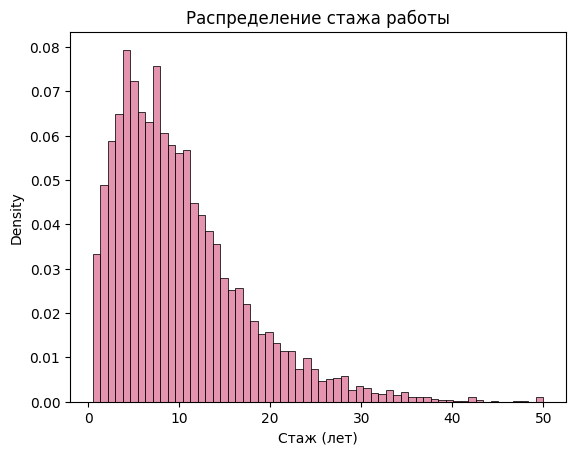

In [7]:
# Посмотрим на распределение стажа
seaborn.histplot(experience,
                 stat='density',
                 color='palevioletred',
                 label='histogram',
                 bins=60)
plt.xlabel('Стаж (лет)')
plt.title('Распределение стажа работы')
plt.show()

### Факт регулярного занятия спортом (бинарная)

In [8]:
# Примерно 55% работников регулярно занимаются спортом
training = np.random.binomial(n=1, p=0.55, size=n)

# Доля занимющихся спортом
print(f'Доля занимющихся спортом: {np.mean(training):.3f}')

Доля занимющихся спортом: 0.552


### Употребление кофе больше трех чашек  (бинарная)

In [9]:
# Примерно 20% работников пью более трех чашек кофе
coffein = np.random.binomial(n=1, p=0.2, size=n)

# Доля пьющих кофе сверх нормы
print(f'Доля пьющих кофе сверх нормы: {np.mean(coffein):.3f}')

Доля пьющих кофе сверх нормы: 0.201


### Качество сна (НЕНАБЛЮДАЕМАЯ переменная, шкала 0–100)

Эта переменная порождает **эндогенность**: она коррелирует и с воздействием (депривацией), и с исходом (производительностью). В анализе она **не используется** как признак.

In [10]:
# Качество сна: chi-квадрат распределение (правоскошенное)
# Среднее ~50, ст.отклонение ~13.7
quality = chi2.rvs(df=8, size=n)*5

# Ограничим диапазон [1, 99] и округлим
quality = np.clip(np.round(quality), 1, 99)

print(quality[0:10])
print(f'Среднее: {quality.mean():.1f}, Ст.откл.: {quality.std():.1f}')

[56. 74. 11. 32. 47. 75. 34. 23. 53. 22.]
Среднее: 39.7, Ст.откл.: 19.6


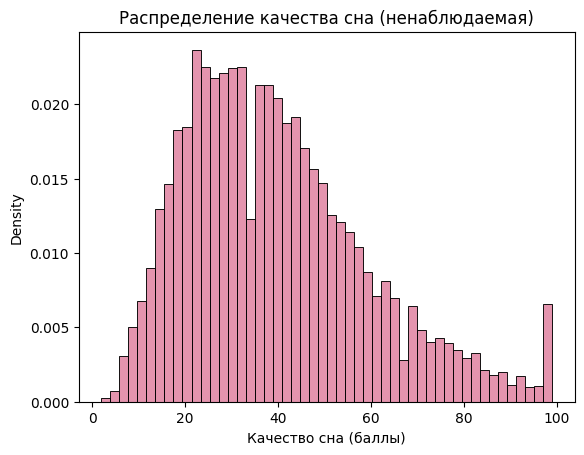

In [11]:
# Распределение качества сна
seaborn.histplot(quality,
                 stat='density',
                 color='palevioletred',
                 label='histogram',
                 bins=50)
plt.xlabel('Качество сна (баллы)')
plt.title('Распределение качества сна (ненаблюдаемая)')
plt.show()

## 2.3. Генерация инструментальной переменной

**Наличие иждивенца до 3 лет** (бинарная). По данным Росстата, примерно 20–22% работающего населения имеют ребёнка до 3 лет. Инструмент генерируется **независимо** от ненаблюдаемого качества сна.

$$\text{P}\left(\text{Child}_{i} = 1|\text{Experience}_{i}, \text{Training}_{i}, \text{Sport}_{i}\right) = \Phi\left(\underbrace{\frac{-0.3 * \text{Experience}_{i}}{ (15 - \text{Training}_{i} + \text{Coffein}_{i})} + 3*\text{Coffein}_{i} - 0.5}_{\text{индекс}}\right)$$

In [12]:
# Сформируем индекс
children_index = (-0.3) * experience / (15 - training + coffein) + coffein * 3 - 0.5

In [13]:
# Создадим условные вероятности
children_prob = norm.cdf(children_index)

# Посмотрим на несколько первых условных вероятностей
print(children_prob[0:10])

[0.28555124 0.19607792 0.99175757 0.97963411 0.30477557 0.26828767
 0.27625606 0.99075421 0.26621998 0.26621998]


In [14]:
# Сгенерируем наличие детей у работников
children = np.random.binomial(n = 1, p = children_prob, size = n)

# Посмотрим на несколько сгенерированных значений
print(children[0:10])

[0 0 1 1 0 0 0 1 1 0]


In [15]:
print(np.var(children_index))

1.4769461110967066


In [16]:
# Доля работников с детьми
print(np.mean(children))

0.3994


## 2.4. Потенциальные исходы переменной воздействия

Депривация сна задаётся через **пороговый метод** с логистической функцией распределения (как в консультации).

Из графа на Deprivation влияют только **Child** (инструмент) и **Quality** (ненаблюдаемая).

Контрольные переменные (стаж, курсы, рабочее место) **не входят** в уравнение воздействия — они влияют только на производительность.

$$P(\text{Deprivation}_{i} = 1|\text{Experience}_{i}, \text{Training}_{i}, \text{Coffein}_{i}, \text{Quality}_{i}, \text{Children}_{i}) = \\ = F_{\text{Logistic}}\left(2\times \ln\left(\text{Quality}_{i} + 1\right) + 5\times\sqrt{\text{Experience}_{i}}\times\text{Coffein}_{i} - \text{Training}_{i}\ - 8 + 0.4\times\text{Children}_{i}\right)$$

In [17]:
# Равномерные случайные величины для порогового метода
u = uniform.rvs(size=n)

# Сгенерируем часть индекса, не зависящую от наличия детей
deprivation_index =  2*np.log (quality + 1) + np.sqrt(experience)*coffein*5 - training - 8


In [18]:
# Симулируем депривацию сна, когда у работника есть ребенок
children1    = 1
deprivation1_index = deprivation_index + 0.4 * children1
deprivation1_prob  = logistic.cdf(deprivation1_index)
deprivation1       = (deprivation1_prob >= u).astype(int)

# Доля людей с депривацией сна, когда у работников есть дети
np.mean(deprivation1)

np.float64(0.4557)

In [19]:

children0    = 0
deprivation0_index = deprivation_index + 0.4 * children0
deprivation0_prob  = logistic.cdf(deprivation0_index)
deprivation0       = (deprivation0_prob >= u).astype(int)


np.mean(deprivation0)

np.float64(0.4011)

In [20]:
# Проверим типы индивидов
ind_type = np.empty(n, dtype='U25')
ind_type[(deprivation1 == 1) & (deprivation0 == 1)] = 'Always taker'
ind_type[(deprivation1 == 0) & (deprivation0 == 0)] = 'Never taker'
ind_type[deprivation1 > deprivation0]               = 'Complier'
ind_type[deprivation1 < deprivation0]               = 'Defier'

print(pd.Series(ind_type).value_counts())

Never taker     5443
Always taker    4011
Complier         546
Name: count, dtype: int64


In [21]:
# Сравним потенциальные исходы воздействия
print(pd.DataFrame(
    data=np.array([deprivation0, deprivation1, ind_type]).transpose(),
    columns=['dep(child=0)', 'dep(child=1)', 'Тип индивида']
).head(15))

   dep(child=0) dep(child=1)  Тип индивида
0             0            0   Never taker
1             0            0   Never taker
2             1            1  Always taker
3             1            1  Always taker
4             0            0   Never taker
5             1            1  Always taker
6             0            0   Never taker
7             1            1  Always taker
8             1            1  Always taker
9             0            0   Never taker
10            0            0   Never taker
11            1            1  Always taker
12            0            0   Never taker
13            1            1  Always taker
14            0            0   Never taker


Наблюдаемый (в данных) уровень депривации можно выразить как:

$$\text{Deprivation}_{i} = \text{Deprivation}_{1i}\times\text{Children}_{i} + \text{Deprivation}_{0i}\times\left(1 - \text{Children}_{i}\right)$$

In [22]:
# Факт наличия у индивида вдепривации сна
deprivation = deprivation1 * children + deprivation0 * (1 - children)

# Доли людей с депривацией
print(np.mean(deprivation))

0.4145


In [23]:
# Рассмотрим корреляции
print(pd.DataFrame(data    = [np.corrcoef(deprivation, quality)[0, 1],
                              np.corrcoef(deprivation, children)[0, 1]],
                   index   = ['Corr(deprivation, quality)',
                              'Corr(deprivation, children)'],
                   columns = ['Оценка']))

                               Оценка
Corr(deprivation, quality)   0.253422
Corr(deprivation, children)  0.411756


## 2.5. Потенциальные исходы зависимой переменной



$$\text{Productivity}_{0i} = \underbrace{\underbrace{0.9\times\text{Quality}_{i}}_{g_{0}^{\text{unobs}}} + \underbrace{12\times\frac{\text{Experience}_{i}}{9 - \text{Training}_{i} - \text{Coffein}_{i}}}_{g_{0}^{\text{obs}}}}_{g_{0}} + \varepsilon_{0i}\text{, где }\varepsilon_{0i}\sim \left(8\times t(15)\right)$$

Уравнение производительности при наличии недосыпа:

$$\text{Productivity}_{1i} = \underbrace{\underbrace{0.6\times \text{Quality}_{i}}_{g_{1}^{\text{unobs}}} + \underbrace{11\times \frac{\text{Experience}_{i}}{10 - \text{Training}_{i} - \text{Coffein}_{i}}}_{g_{1}^{\text{obs}}}}_{g_{1}} + \varepsilon_{1i}\text{, где }\varepsilon_{1i}\sim \left(\text{EXP}(0.1) - 10\right)$$

Наблюдаемая производительность:

$$\text{Productivity}_{i} = \text{Productivity}_{1i}\times\text{Deprivation}_{i} + \text{Productivity}_{0i}\times\left(1-\text{Deprivation}_{i}\right)$$

In [ ]:
# Случайные ошибки
error0 = t.rvs(size = n, df = 15) * 8
error1 = expon.rvs(size = n, scale = 10) - 10

# Функция от контрольных переменных когда у индивида нет депривации
g0_obs   = 12 * experience / (9 - training - coffein)
g0_unobs =  0.9 * quality
g0       = g0_obs + g0_unobs
  # когда у индивида есть депривация
g1_obs   = 11 * experience / (10 - training - coffein)
g1_unobs =  0.6 * quality
g1       = g1_obs + g1_unobs

# Продуктивность в зависимости от наличия депривации сна
productivity0 = g0 + error0
productivity1 = g1 + error1

# Наблюдаемая продуктивность
productivity = productivity1 * deprivation + productivity0 * (1 - deprivation)
productivity = np.maximum(productivity, 0)

In [25]:
# Приблизительно оценим адекватность дисперсий
print(pd.DataFrame(data    = [np.var(error0),   np.var(g0),
                              np.var(g0_obs),   np.var(g0_unobs),
                              np.var(error1),   np.var(g1),
                              np.var(g1_obs),   np.var(g1_unobs)],
                   index   = ['Var(eps0)',     'Var(g0)',
                              'Var(g0_obs)',   'Var(g0_unobs)',
                              'Var(eps1)',     'Var(g1)',
                              'Var(g1_obs)',   'Var(g1_unobs)'],
                   columns = ['Оценка']))

                   Оценка
Var(eps0)       76.388250
Var(g0)        424.427889
Var(g0_obs)    109.226881
Var(g0_unobs)  311.862171
Var(eps1)       99.506274
Var(g1)        212.952040
Var(g1_obs)     72.491091
Var(g1_unobs)  138.605410


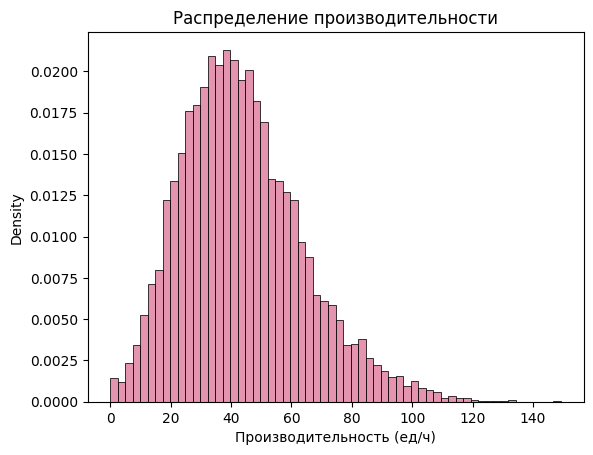

In [26]:
seaborn.histplot(productivity,
                 stat='density',
                 color='palevioletred',
                 label='histogram',
                 bins=60)
plt.xlabel('Производительность (ед/ч)')
plt.title('Распределение производительности')
plt.show()

In [27]:
# Аггрегируем данные в датафрейм
df = pd.DataFrame({'productivity': productivity, 'deprivation': deprivation,
                   'experience': experience, 'coffein': coffein,
                   'training': training, 'children': children})
df = df.loc[0:n, :]

# Посмотрим на симулированные данные
df.head(10).style.format(precision = 2)

,productivity,deprivation,experience,coffein,training,children
0,58.77,0,3.10,0,1,0
1,94.73,0,16.60,0,1,0
2,4.89,1,5.10,1,1,1
3,54.82,1,24.20,1,0,1
4,46.81,0,0.50,0,1,0
5,61.31,1,5.90,0,0,0
6,45.60,0,4.70,0,0,0
7,27.87,1,7.70,1,0,1
8,29.25,1,5.80,0,1,1
9,26.67,0,5.80,0,1,0


In [28]:
df.describe()

,productivity,deprivation,experience,coffein,training,children
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.0000
mean,43.739048,0.41450,10.076730,0.201000,0.552000,0.3994
std,20.186143,0.49266,7.057703,0.400768,0.497314,0.4898
min,0.000000,0.00000,0.500000,0.000000,0.000000,0.0000
25%,29.212132,0.00000,4.800000,0.000000,0.000000,0.0000
50%,41.494980,0.00000,8.500000,0.000000,1.000000,0.0000
75%,55.838494,1.00000,13.500000,0.000000,1.000000,1.0000
max,149.225003,1.00000,50.000000,1.000000,1.000000,1.0000


In [29]:
df['deprivation'].value_counts()

deprivation
0    5855
1    4145
Name: count, dtype: int64

In [30]:
df['training'].value_counts()

training
1    5520
0    4480
Name: count, dtype: int64

In [31]:
df['coffein'].value_counts()

coffein
0    7990
1    2010
Name: count, dtype: int64

In [32]:
df.median()

productivity    41.49498
deprivation      0.00000
experience       8.50000
coffein          0.00000
training         1.00000
children         0.00000
dtype: float64

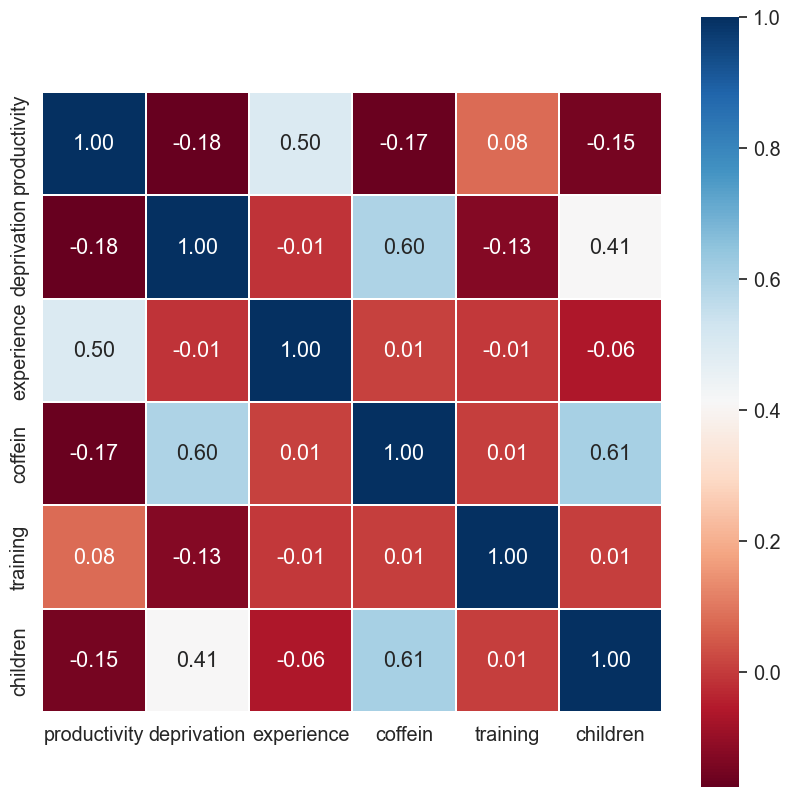

In [33]:
plt.figure(figsize = (10, 10))
seaborn.set(font_scale = 1.3)

seaborn.heatmap(df.corr(method='pearson'),
            square=True, annot=True, fmt=".2f",
            linewidths=0.1, cmap="RdBu");

In [34]:
#Разделим выборку на тестовую и обучающую
from sklearn.model_selection import train_test_split
X=df.drop(columns='productivity')
y=df['productivity']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

## 3. Классификация

В этом разделе сравниваются классификаторы `KNN`, `LogReg` и `RandomForest`.

Целевая переменная — `deprivation`; в качестве признаков используются `training`, `coffein`, `children` и `experience`.

In [35]:
np.random.seed(123)
X_train_c=X_train.drop(columns='deprivation')
X_test_c=X_test.drop(columns='deprivation')
y_train_c=X_train['deprivation']
y_test_c=X_test['deprivation']

In [36]:
# Базовый запуск моделей с дефолтными параметрами
logreg = LogisticRegression(max_iter=3000)
logreg.fit(X_train_c, y_train_c)
knn = KNeighborsClassifier()
knn.fit(X_train_c, y_train_c)
forest = RandomForestClassifier(random_state=42)
forest.fit(X_train_c, y_train_c)

columns=['train','test','cv']
default_accuracy=[]

## 3.2. Дефолтная реализация и подбор параметров

In [37]:
models = {
    'LogReg': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'RandomForest': RandomForestClassifier(),
}

log_grid = {
    'C': [0.05, 0.2, 1, 5, 15],
    'tol': [0.00001, 0.0001, 0.001],
    'penalty': ['l1', 'l2']
}
KNN_grid = {
    'n_neighbors': [2, 5, 11, 21, 31, 50],
    'weights': ['uniform', 'distance'],
    'p': [1, 2, 5]
}
forest_grid = {
    'n_estimators': [200, 400, 700],
    'max_depth': [4, 8, None],
    'min_samples_leaf': [1, 3, 7],
    'criterion': ['gini', 'entropy']
}

param_grids = {
    'LogReg': log_grid,
    'KNN': KNN_grid,
    'RandomForest': forest_grid,
}

# Таблица 1: только дефолтные параметры
default_records = []
# Таблица 2: исходные + подобранные гиперпараметры и качество до/после тюнинга
comparison_records = []

best_models = {}

In [38]:
# Шаг 1. Оценка моделей с дефолтными параметрами
for name, model in models.items():
    model.fit(X_train_c, y_train_c)
    train_pred_default = model.predict(X_train_c)
    test_pred_default = model.predict(X_test_c)
    cv_acc_default = cross_val_score(model, X_train_c, y_train_c, cv=5, scoring='accuracy').mean()

    default_records.append({
        'model': name,
        'default_params': str(model.get_params()),
        'train_acc_default': accuracy_score(y_train_c, train_pred_default),
        'test_acc_default': accuracy_score(y_test_c, test_pred_default),
        'cv_acc_default': cv_acc_default,
    })

default_results_table = pd.DataFrame(default_records).sort_values('test_acc_default', ascending=False)
print('Таблица 1. Результаты моделей с дефолтными параметрами')
display(default_results_table)

Таблица 1. Результаты моделей с дефолтными параметрами


,model,default_params,train_acc_default,test_acc_default,cv_acc_default
0,LogReg,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.786000,0.7865,0.786000
2,RandomForest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.812875,0.7645,0.747875
1,KNN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",0.788125,0.7440,0.738500


In [39]:
# Шаг 2. Подбор гиперпараметров и сравнение до/после тюнинга
for name, model in models.items():
    row_default = default_results_table.loc[default_results_table['model'] == name].iloc[0]

    gs = GridSearchCV(model, param_grids[name], scoring='accuracy', cv=5, n_jobs=-1)
    gs.fit(X_train_c, y_train_c)

    tuned_model = gs.best_estimator_
    best_models[name] = tuned_model
    test_pred_tuned = tuned_model.predict(X_test_c)

    comparison_records.append({
        'model': name,
        'initial_params': str(model.get_params()),
        'best_params': str(gs.best_params_),
        'cv_acc_before': row_default['cv_acc_default'],
        'test_acc_before': row_default['test_acc_default'],
        'cv_acc_after': gs.best_score_,
        'test_acc_after': accuracy_score(y_test_c, test_pred_tuned),
    })

comparison_table = pd.DataFrame(comparison_records).sort_values('test_acc_after', ascending=False)
print('Таблица 2. Сравнение до/после тюнинга (параметры + CV accuracy + test accuracy)')
display(comparison_table)

Таблица 2. Сравнение до/после тюнинга (параметры + CV accuracy + test accuracy)


,model,initial_params,best_params,cv_acc_before,test_acc_before,cv_acc_after,test_acc_after
0,LogReg,"{'C': 1.0, 'class_weight': None, 'dual': False...","{'C': 0.05, 'penalty': 'l2', 'tol': 1e-05}",0.786000,0.7865,0.786000,0.7865
2,RandomForest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...","{'criterion': 'gini', 'max_depth': 4, 'min_sam...",0.747875,0.7645,0.786000,0.7865
1,KNN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...","{'n_neighbors': 50, 'p': 1, 'weights': 'uniform'}",0.738500,0.7440,0.782375,0.7835


## 3.3. Альтернативный критерий — F1
Нам важно хорошо отделять положительные исходы переменной воздействия от отрицательных, чтобы корректно моделировать её взаимосвязь с зависимой переменной.

In [40]:
default_records_f1 = []
# Таблица 2: исходные + подобранные гиперпараметры и качество до/после тюнинга
comparison_records_f1 = []

best_models_f1 = {}

# Шаг 1. Дефолтные модели по метрике F1
for name, model in models.items():
    model.fit(X_train_c, y_train_c)
    train_pred_default = model.predict(X_train_c)
    test_pred_default = model.predict(X_test_c)
    cv_f1_default = cross_val_score(model, X_train_c, y_train_c, cv=5, scoring='f1').mean()

    default_records_f1.append({
        'model': name,
        'default_params': str(model.get_params()),
        'train_f1_default': f1_score(y_train_c, train_pred_default),
        'test_f1_default': f1_score(y_test_c, test_pred_default),
        'cv_f1_default': cv_f1_default,
    })

default_results_table_f1 = pd.DataFrame(default_records_f1).sort_values('test_f1_default', ascending=False)
print('Таблица 1. Результаты моделей с дефолтными параметрами')
display(default_results_table_f1)

Таблица 1. Результаты моделей с дефолтными параметрами


,model,default_params,train_f1_default,test_f1_default,cv_f1_default
2,RandomForest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.731383,0.667131,0.650128
0,LogReg,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.651749,0.655367,0.651680
1,KNN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",0.708713,0.654054,0.639688


In [41]:
# Шаг 2. Тюнинг моделей по F1 и сравнение до/после
for name, model in models.items():
    row_default = default_results_table_f1.loc[default_results_table_f1['model'] == name].iloc[0]

    gs_f1 = GridSearchCV(model, param_grids[name], scoring='f1', cv=5, n_jobs=-1)
    gs_f1.fit(X_train_c, y_train_c)

    tuned_model_f1 = gs_f1.best_estimator_
    best_models_f1[name] = tuned_model_f1
    test_pred_tuned_f1 = tuned_model_f1.predict(X_test_c)

    comparison_records_f1.append({
        'model': name,
        'initial_params': str(model.get_params()),
        'best_params': str(gs_f1.best_params_),
        'cv_f1_before': row_default['cv_f1_default'],
        'test_f1_before': row_default['test_f1_default'],
        'cv_f1_after': gs_f1.best_score_,
        'test_f1_after': f1_score(y_test_c, test_pred_tuned_f1),
    })

comparison_table_f1 = pd.DataFrame(comparison_records_f1).sort_values('test_f1_after', ascending=False)
print('Таблица 2. Сравнение до/после тюнинга (параметры + CV accuracy + test f1)')
display(comparison_table_f1)

Таблица 2. Сравнение до/после тюнинга (параметры + CV accuracy + test f1)


,model,initial_params,best_params,cv_f1_before,test_f1_before,cv_f1_after,test_f1_after
1,KNN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...","{'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}",0.639688,0.654054,0.654239,0.659259
2,RandomForest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...","{'criterion': 'gini', 'max_depth': None, 'min_...",0.650128,0.667131,0.658088,0.657576
0,LogReg,"{'C': 1.0, 'class_weight': None, 'dual': False...","{'C': 0.05, 'penalty': 'l2', 'tol': 1e-05}",0.651680,0.655367,0.651680,0.655367


Повышенная сложность OOB-ошибки

In [42]:
from sklearn.model_selection import ParameterGrid

best_score = 0

for params in ParameterGrid(forest_grid):
    forest = RandomForestClassifier(
        oob_score=True,
        bootstrap=True,
        random_state=42,
        n_jobs=-1,
        **params,
    )
    forest.fit(X_train_c, y_train_c)
    if forest.oob_score_ > best_score:
        best_score = forest.oob_score_
        best_params = params
        best_forest = forest

rf_cv_best = best_models['RandomForest']

rf_compare_oob_cv = pd.DataFrame([
    {
        'variant': 'RF tuned by CV',
        'params': rf_cv_best.get_params(),
        'test_accuracy': accuracy_score(y_test_c, rf_cv_best.predict(X_test_c)),
    },
    {
        'variant': 'RF tuned by OOB',
        'params': best_params,
        'oob_score': best_score,
        'test_accuracy': accuracy_score(y_test_c, best_forest.predict(X_test_c)),
    },
])

print('Лучшие параметры по OOB:', best_params)
rf_compare_oob_cv

Лучшие параметры по OOB: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 7, 'n_estimators': 200}


,variant,params,test_accuracy,oob_score
0,RF tuned by CV,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.7865,NaN
1,RF tuned by OOB,"{'criterion': 'gini', 'max_depth': 4, 'min_sam...",0.7865,0.786


## 3.4. ROC-AUC

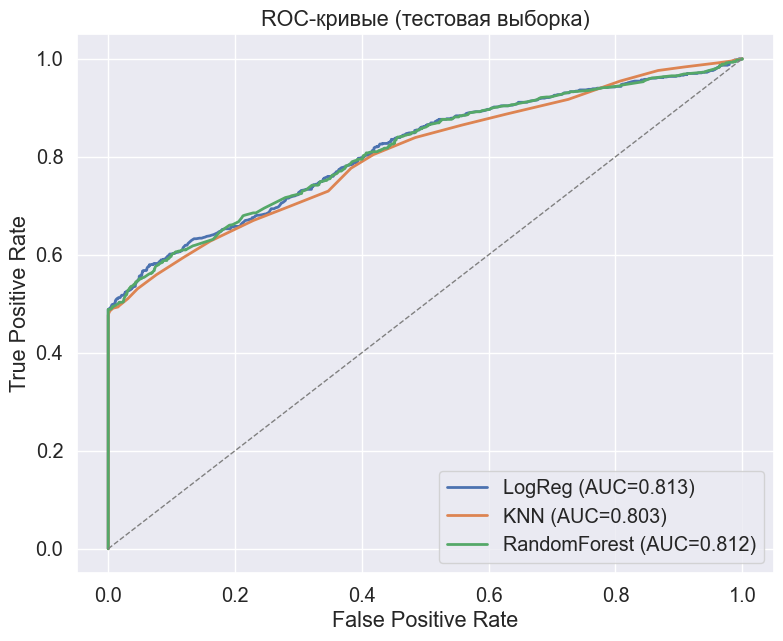

,model,AUC
0,LogReg,0.813098
2,RandomForest,0.812234
1,KNN,0.803485


In [43]:
plt.figure(figsize=(9, 7))
auc_rows = []

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, y_prob)
    auc_value = roc_auc_score(y_test_c, y_prob)
    auc_rows.append({'model': name, 'AUC': auc_value})
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_value:.3f})')

plt.plot([0, 1], [0, 1], '--', color='gray', lw=1)
plt.title('ROC-кривые (тестовая выборка)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

auc_table = pd.DataFrame(auc_rows).sort_values('AUC', ascending=False)
auc_table

## 3.5. Матрица ошибок

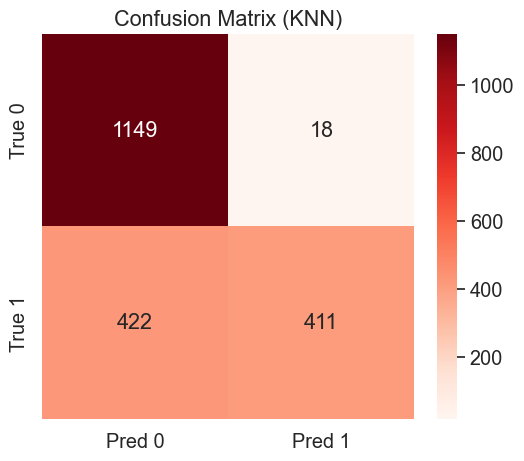

,Pred 0,Pred 1
True 0,1149,18
True 1,422,411


In [44]:
best_model = best_models['KNN']

y_prob_best = best_model.predict_proba(X_test_c)[:, 1]
y_pred_05 = (y_prob_best >= 0.5).astype(int)

cm = confusion_matrix(y_test_c, y_pred_05)
cm_df = pd.DataFrame(cm, index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1'])

plt.figure(figsize=(6, 5))
seaborn.heatmap(cm_df, annot=True, fmt='d', cmap='Reds')
plt.title(f'Confusion Matrix (KNN)')
plt.show()

cm_df

## 3.6. Подбор порогов

In [45]:
thresholds = [0.2,0.55, 0.8]
threshold_rows = []
y_true = y_test_c.to_numpy()
for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    threshold_rows.append({
        'threshold': t,
        'ACC': accuracy_score(y_test_c, y_pred_t),
        'Precision': precision_score(y_test_c, y_pred_t),
        'Recall': recall_score(y_test_c, y_pred_t),
        'TP': ((y_pred_t == 1) & (y_true == 1)).sum(),
        'FP': ((y_pred_t == 1) & (y_true == 0)).sum(),
        'FN': ((y_pred_t == 0) & (y_true == 1)).sum(),
        'TN': ((y_pred_t == 0) & (y_true == 0)).sum(),
    })

threshold_table = pd.DataFrame(threshold_rows)
threshold_table

,threshold,ACC,Precision,Recall,TP,FP,FN,TN
0,0.20,0.5420,0.474240,0.917167,764,847,69,320
1,0.55,0.7840,0.992629,0.484994,404,3,429,1164
2,0.80,0.7775,1.000000,0.465786,388,0,445,1167


## 3.7. Оптимизация прибыли

**Прикладная задача:** HR-аналитика в компании, озабоченной снижением продуктивности своих работников.   

- Если прогноз `deprivation=1` (высокий риск недосыпа), сотруднику назначают профилактические меры: гибкий график, консультации психолога, перераспределение нагрузки.
- Если прогноз `deprivation=0`, дополнительных действий не предпринимают.
$$\text{Profit}(c_{i}) = p_{\text{TP}} \times \text{TP}(c_{i}) + p_{\text{TN}} \times \text{TN}c_{i}  + p_{\text{FP}} \times \text{FP}(c_{i}) + p_{\text{FN}} \times \text{FN}c_{i}$$
Если у работника есть депривация, то компания тратит деньги на его адаптацию, но в итоге получает больше чем потратила за счет роста производительности. Если депривации нет, то компания не тратит ничего и ничего не получает, потому что работник выдает уже свою "пиковую" производительность.


In [46]:
def linear_profit(y_true, y_prob, threshold, tp=8, fp=-5, fn=-13, tn=0):
    y_pred = (y_prob >= threshold).astype(int)
    tp_n = ((y_pred == 1) & (y_true == 1)).sum()
    fp_n = ((y_pred == 1) & (y_true == 0)).sum()
    fn_n = ((y_pred == 0) & (y_true == 1)).sum()
    tn_n = ((y_pred == 0) & (y_true == 0)).sum()
    return tp * tp_n + fp * fp_n + fn * fn_n + tn * tn_n


profit_rows_linear = []

for name, model in best_models.items():
    train_prob = model.predict_proba(X_train_c)[:, 1]
    test_prob = model.predict_proba(X_test_c)[:, 1]

    threshold_candidates = np.unique(model.predict_proba(X_train_c))

    train_linear_vals = np.array([
        linear_profit(y_train_c, train_prob, t) for t in threshold_candidates
    ])
    best_t_linear = float(threshold_candidates[np.argmax(train_linear_vals)])

    profit_rows_linear.append({
        'model': name,
        'best_threshold_train': best_t_linear,
        'test_profit': linear_profit(y_test_c, test_prob, best_t_linear)})

profit_table_linear = pd.DataFrame(profit_rows_linear).sort_values('test_profit', ascending=False)
profit_table_linear

,model,best_threshold_train,test_profit
2,RandomForest,0.198524,1364
0,LogReg,0.196779,1348
1,KNN,0.200000,980


## 3.8. Байесовские сети

In [47]:
train_data = X_train_c.copy()
test_data = X_test_c.copy()
train_data['deprivation'] = y_train_c
test_data['deprivation'] = y_test_c

In [48]:
train_data['experience_bin'] = pd.qcut(train_data['experience'], q = 4, labels = range(0, 4))
test_data['experience_bin'] = pd.qcut(test_data['experience'], q = 4, labels = range(0, 4))

In [49]:
train_data1=train_data.drop(columns='experience')
test_data1=test_data.drop(columns='experience')

[bnlearn]> Auto generate placeholders for the CPTs.
[bnlearn] >CPT for deprivation:
+----------------+-----+-------------------+
| training       | ... | training(1)       |
+----------------+-----+-------------------+
| coffein        | ... | coffein(1)        |
+----------------+-----+-------------------+
| experience_bin | ... | experience_bin(1) |
+----------------+-----+-------------------+
| children       | ... | children(1)       |
+----------------+-----+-------------------+
| deprivation(0) | ... | 0.5               |
+----------------+-----+-------------------+
| deprivation(1) | ... | 0.5               |
+----------------+-----+-------------------+
[bnlearn] >CPT for children:
+----------------+-------------------+-------------------+
| experience_bin | experience_bin(0) | experience_bin(1) |
+----------------+-------------------+-------------------+
| children(0)    | 0.5               | 0.5               |
+----------------+-------------------+-------------------+
| child

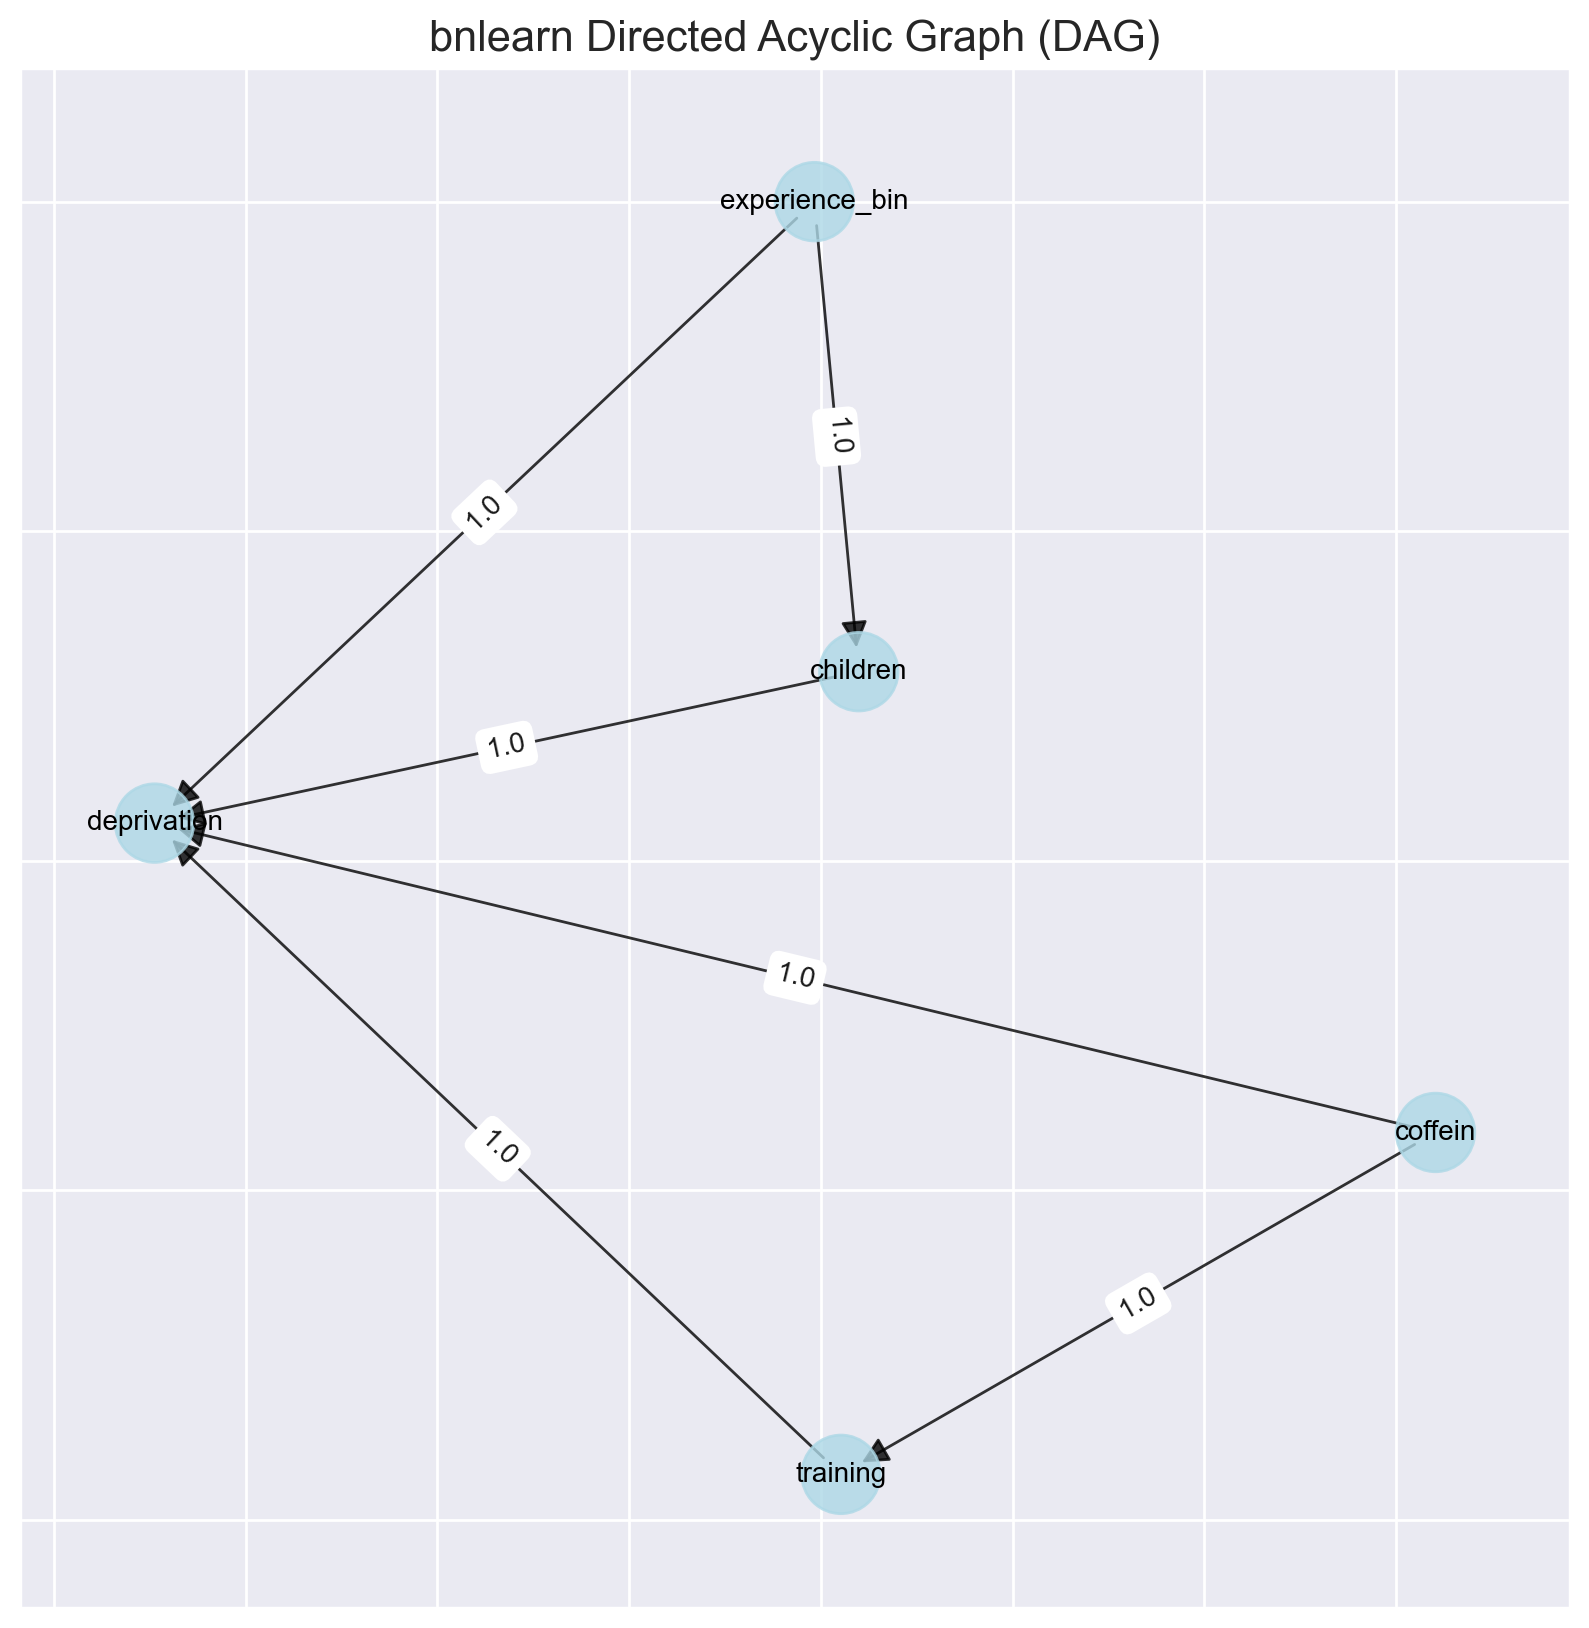

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'training': array([ 0.02628141, -0.93125949]),
  'deprivation': array([-0.86887402,  0.05696513]),
  'coffein': array([ 0.80154209, -0.41245649]),
  'experience_bin': array([-0.00844759,  1.        ]),
  'children': array([0.04949811, 0.28675085])},
 'G': <networkx.classes.digraph.DiGraph at 0x132d14340>,
 'node_properties': {'training': {'node_color': '#ADD8E6', 'node_size': 800},
  'deprivation': {'node_color': '#ADD8E6', 'node_size': 800},
  'coffein': {'node_color': '#ADD8E6', 'node_size': 800},
  'experience_bin': {'node_color': '#ADD8E6', 'node_size': 800},
  'children': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties': {('training', 'deprivation'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 1,
   'value': np.float64(1.0)},
  ('coffein', 'training'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 1,
   'value': np.float64(1.0)},
 

In [50]:
edges = [("training", "deprivation"),
               ("coffein", "deprivation"),
               ('experience_bin','deprivation'),
              ('experience_bin','children'),
               ("children", "deprivation"),
               ("coffein", "training")]
DAG = bn.make_DAG(edges)
bn.plot(DAG)

In [51]:
bn_self = bn.parameter_learning.fit(DAG, train_data1)
predict_bn_test = bn.predict(bn_self, df = test_data1, variables = 'deprivation')
prediction_bn_test = np.array(predict_bn_test.loc[:, 'deprivation'])

acc_self = (prediction_bn_test == y_test_c).mean()
print(f'Значение accuracy для предполагаемой Байесовской сети на тесте: {acc_self}')

[bnlearn] >Parameter learning> Computing parameters using [bayes]


[bnlearn] >CPD of deprivation:
+----------------+-----+---------------------+
| children       | ... | children(1)         |
+----------------+-----+---------------------+
| coffein        | ... | coffein(1)          |
+----------------+-----+---------------------+
| experience_bin | ... | experience_bin(3)   |
+----------------+-----+---------------------+
| training       | ... | training(1)         |
+----------------+-----+---------------------+
| deprivation(0) | ... | 0.06194251734390486 |
+----------------+-----+---------------------+
| deprivation(1) | ... | 0.9380574826560951  |
+----------------+-----+---------------------+
[bnlearn] >CPD of children:
+----------------+-----+--------------------+
| experience_bin | ... | experience_bin(3)  |
+----------------+-----+--------------------+
| children(0)    | ... | 0.6244970943227537 |
+----------------+-----+--------------------+
| children(1)    | ... | 0.3755029056772463 |
+----------------+-----+--------------------+
[bnlearn

100%|██████████| 25/25 [00:00<00:00, 2350.49it/s]

Значение accuracy для предполагаемой Байесовской сети на тесте: 0.7865


In [52]:
bn_train_structure = bn.structure_learning.fit(train_data1,
                                                     methodtype = 'hc',
                                                     scoretype  = 'bic')

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).


[bnlearn] >No changes made to existing bayes DAG.
[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


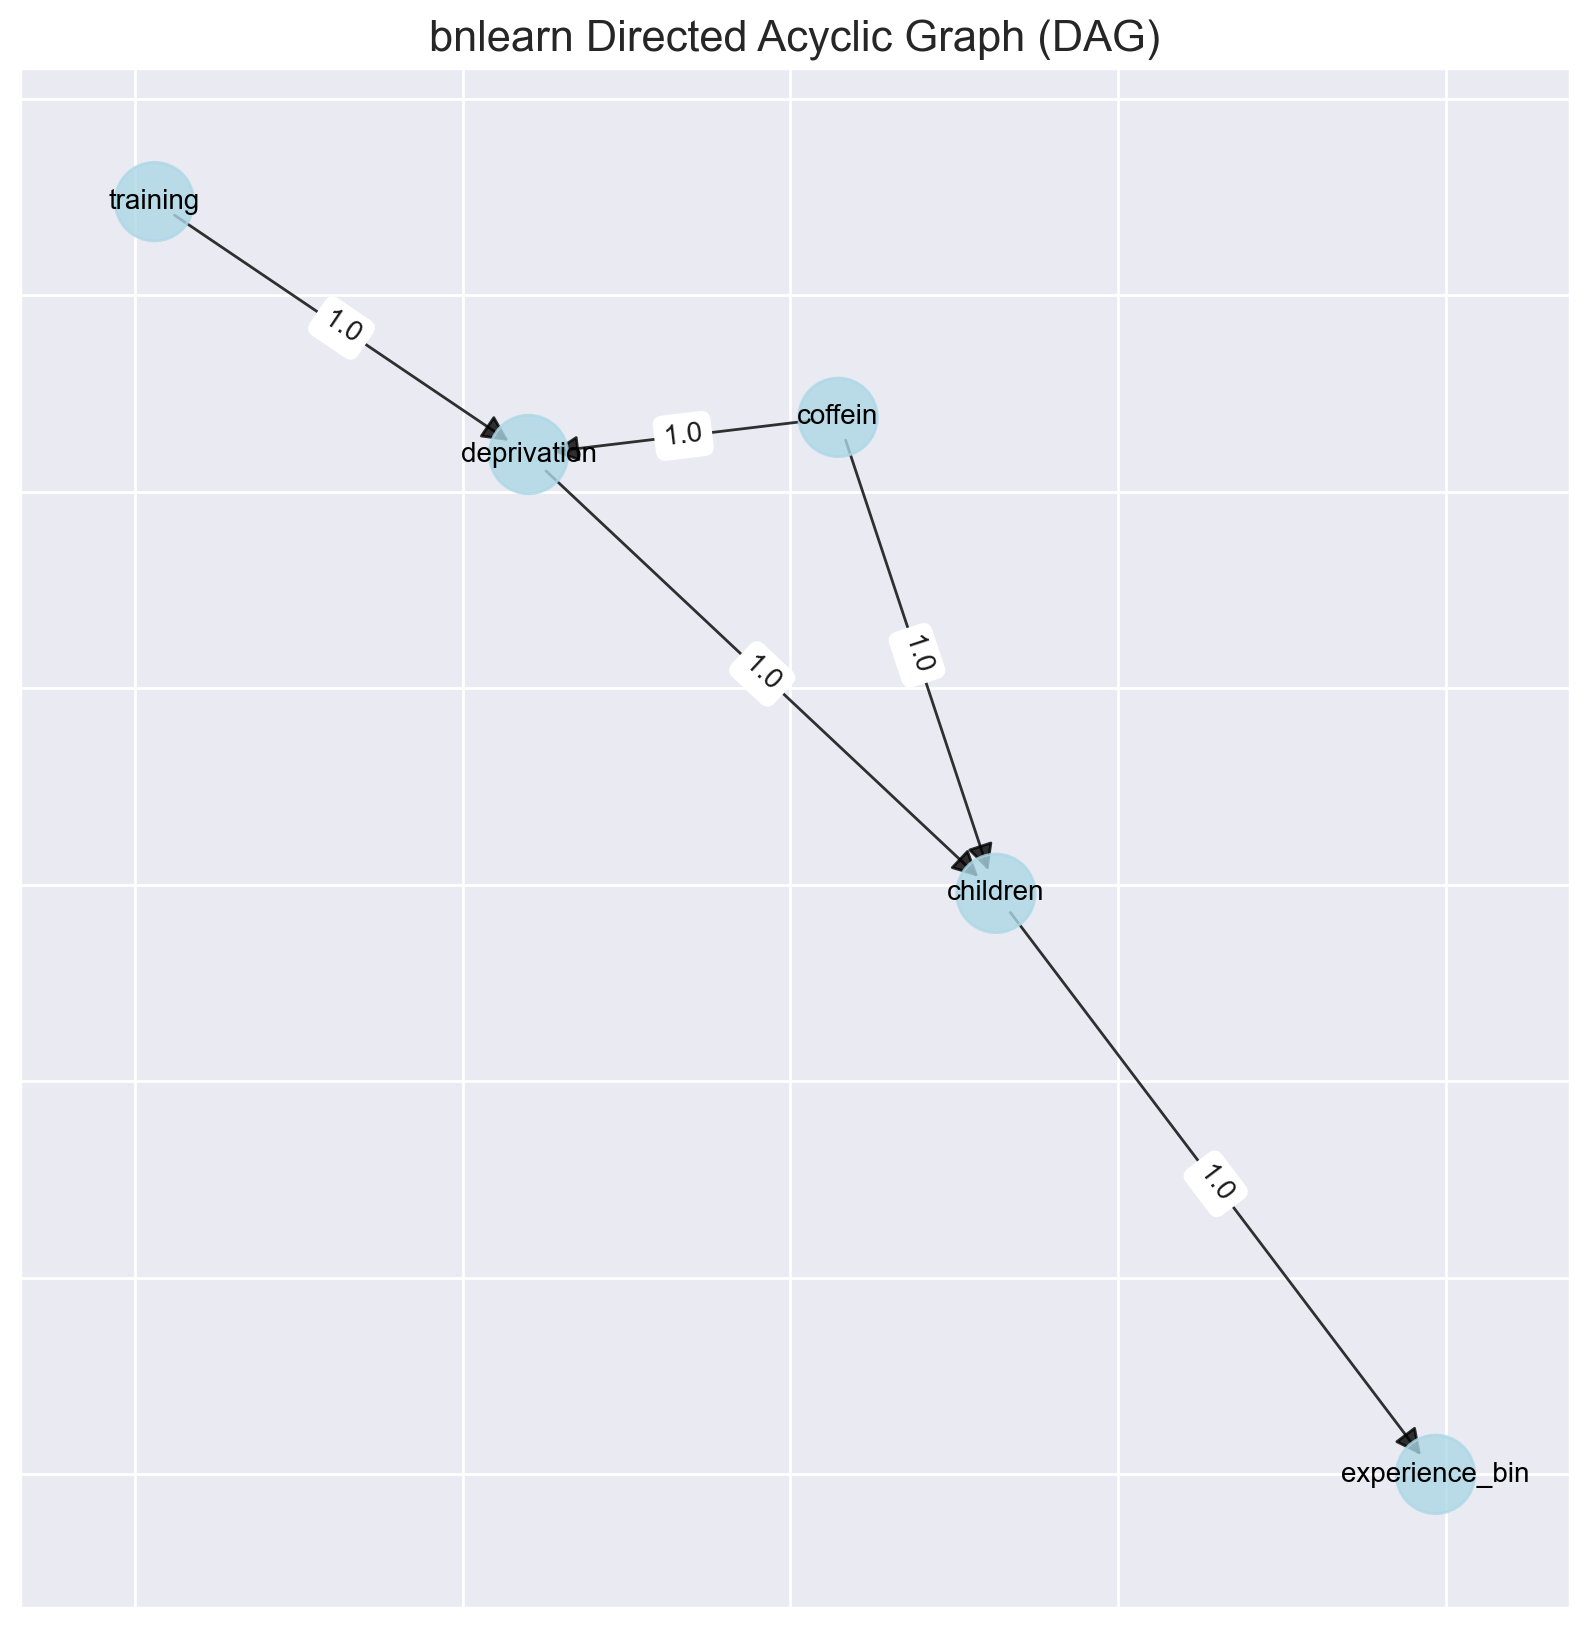

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'coffein': array([0.07257535, 0.34458911]),
  'children': array([ 0.31345436, -0.26089316]),
  'deprivation': array([-0.39980645,  0.29735092]),
  'training': array([-0.97059551,  0.61895313]),
  'experience_bin': array([ 0.98437224, -1.        ])},
 'G': <networkx.classes.digraph.DiGraph at 0x132e96c40>,
 'node_properties': {'coffein': {'node_color': '#ADD8E6', 'node_size': 800},
  'training': {'node_color': '#ADD8E6', 'node_size': 800},
  'children': {'node_color': '#ADD8E6', 'node_size': 800},
  'deprivation': {'node_color': '#ADD8E6', 'node_size': 800},
  'experience_bin': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties': {('coffein', 'children'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 1,
   'value': np.float64(1.0)},
  ('coffein', 'deprivation'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 1,
   'value': np.float64(1.0)},
  

In [53]:
DAG1 = bn.make_DAG(bn_train_structure)
if 'config' not in DAG1:
    DAG1['config'] = {'method': 'bayes'}
bn.plot(DAG1)

In [54]:

bn_self1 = bn.parameter_learning.fit(DAG1, train_data1)
predict_bn_test1 = bn.predict(bn_self1, df = test_data1, variables = 'deprivation')
prediction_bn_test1 = np.array(predict_bn_test1.loc[:, 'deprivation'])

acc_self1 = (prediction_bn_test1 == y_test_c).mean()
print(f'Значение accuracy для обученной Байесовской сети на тесте: {acc_self1}')

[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >Converting [<class 'pgmpy.base.DAG.DAG'>] to BayesianNetwork model.
[bnlearn] >Converting adjmat to BayesianNetwork.
[bnlearn] >CPD of coffein:
+------------+----------+
| coffein(0) | 0.766222 |
+------------+----------+
| coffein(1) | 0.233778 |
+------------+----------+
[bnlearn] >CPD of children:
+-------------+--------------------+-----+---------------------+
| coffein     | coffein(0)         | ... | coffein(1)          |
+-------------+--------------------+-----+---------------------+
| deprivation | deprivation(0)     | ... | deprivation(1)      |
+-------------+--------------------+-----+---------------------+
| children(0) | 0.7530388978930308 | ... | 0.07667386609071274 |
+-------------+--------------------+-----+---------------------+
| children(1) | 0.2469611021069692 | ... | 0.9233261339092873  |
+-------------+--------------------+-----+---------------------+
[bnlearn] >CPD of deprivation:
+----

100%|██████████| 25/25 [00:00<00:00, 2550.22it/s]

Значение accuracy для обученной Байесовской сети на тесте: 0.7865


Повышенная сложность - ROC-AUC

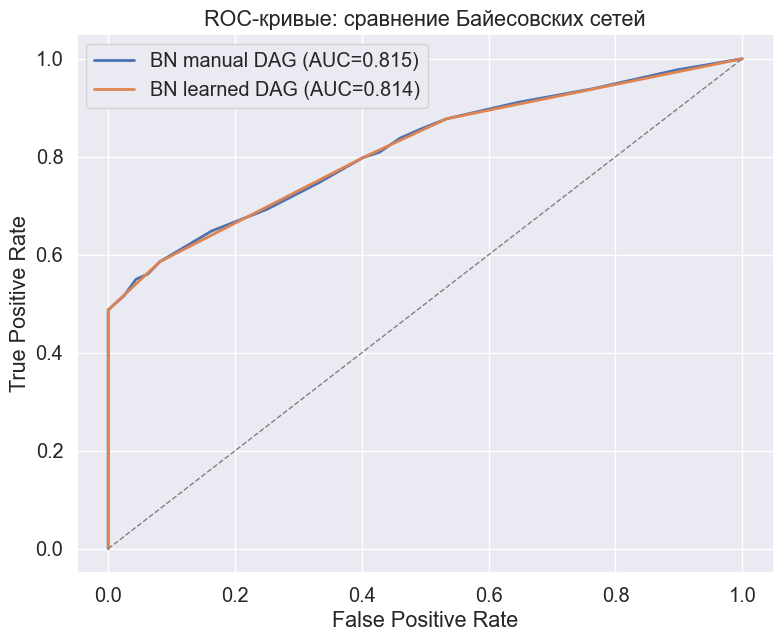

In [ ]:
y_true_bn = y_test_c

bn_label_manual = np.asarray(predict_bn_test['deprivation']).ravel()
bn_prob_manual = np.where(
    bn_label_manual == 1,
    predict_bn_test['p'].values,
    1 - predict_bn_test['p'].values,
)

bn_label_learned = np.asarray(predict_bn_test1['deprivation']).ravel()
bn_prob_learned = np.where(
    bn_label_learned == 1,
    predict_bn_test1['p'].values,
    1 - predict_bn_test1['p'].values,
)

# ROC-кривые и AUC: две версии БС
plt.figure(figsize=(9, 7))
auc_compare_rows = []


fpr_manual, tpr_manual, _ = roc_curve(y_true_bn, bn_prob_manual)
auc_manual = roc_auc_score(y_true_bn, bn_prob_manual)
auc_compare_rows.append({'model': 'BayesianNetwork_manual_DAG', 'AUC': auc_manual})
plt.plot(fpr_manual, tpr_manual, lw=2, label=f'BN manual DAG (AUC={auc_manual:.3f})')

fpr_learned, tpr_learned, _ = roc_curve(y_true_bn, bn_prob_learned)
auc_learned = roc_auc_score(y_true_bn, bn_prob_learned)
auc_compare_rows.append({'model': 'BayesianNetwork_learned_DAG', 'AUC': auc_learned})
plt.plot(fpr_learned, tpr_learned, lw=2, label=f'BN learned DAG (AUC={auc_learned:.3f})')

plt.plot([0, 1], [0, 1], '--', color='gray', lw=1)
plt.title('ROC-кривые: сравнение Байесовских сетей')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

auc_compare_table = pd.DataFrame(auc_compare_rows).sort_values('AUC', ascending=False)

## 3.9. Выбор лучшей и худшей моделей

In [56]:
all_model_ranking = []

# Классические модели (порог 0.5)
for name, model in best_models.items():
    prob_test = model.predict_proba(X_test_c)[:, 1]
    pred_test = (prob_test >= 0.5).astype(int)

    all_model_ranking.append({
        'model': name,
        'f1_test': f1_score(y_test_c, pred_test),
        'AUC_test': roc_auc_score(y_test_c, prob_test),
        'threshold': 0.5,
    })

# Байесовская сеть (обученный DAG, порог 0.5)
bn_label = predict_bn_test1['deprivation'].values
bn_prob1 = np.where(bn_label == 1,
                    predict_bn_test1['p'].values,
                    1 - predict_bn_test1['p'].values)
all_model_ranking.append({
    'model': 'BayesianNetwork_K2',
    'f1_test': f1_score(y_test_c, bn_label),
    'AUC_test': roc_auc_score(y_test_c, bn_prob1),
    'threshold': 0.5,
})

final_ranking = pd.DataFrame(all_model_ranking).sort_values(
    ['f1_test',"AUC_test"], ascending=False
)

best_model_overall = final_ranking.iloc[0]['model']
worst_model_overall = final_ranking.iloc[-1]['model']

print('Лучшая модель по f1:', best_model_overall)
print('Худшая модель по f1:', worst_model_overall)
final_ranking

Лучшая модель по f1: BayesianNetwork_K2
Худшая модель по f1: KNN


,model,f1_test,AUC_test,threshold
3,BayesianNetwork_K2,0.655367,0.813668,0.5
0,LogReg,0.655367,0.813098,0.5
2,RandomForest,0.655367,0.812234,0.5
1,KNN,0.651347,0.803485,0.5


## 4. Регрессия
В этом разделе сравниваются методы `OLS`, `KNN`, `RandomForest` и `GradientBoosting`.
Для прогноза `productivity` используются признаки `experience`, `coffein`, `training` и `children`.
Переменная воздействия `deprivation` из регрессии исключена, а ненаблюдаемая `quality` в данных отсутствует.


## 4.1. Отбор переменных

In [57]:
np.random.seed(123)
X_train_r=X_train.drop(columns=['deprivation'])
X_test_r=X_test.drop(columns=['deprivation'])
y_train_r=y_train
y_test_r=y_test

## 4.2. Дефолтная реализация и подбор параметров

In [58]:
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# MAPE в %. productivity обрезана снизу нулём, поэтому есть значения = 0, на которых MAPE не определена -> при расчёте исключаем наблюдения < 1
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true >= 1.0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_scorer = make_scorer(mape, greater_is_better=False)

models = {
    'Ridge-OLS': Ridge(),
    'KNN': KNeighborsRegressor(),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
}

ridge_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'tol':[0.0001,0.001,0.01],
    'fit_intercept':[True,False]
}
KNN_grid = {
    'n_neighbors': [5, 11, 21, 35, 51],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
forest_grid = {
    'n_estimators': [200, 400],
    'max_depth': [6, 12, None],
    'min_samples_leaf': [1, 5, 20]
}

param_grids = {
    'Ridge-OLS': ridge_grid,
    'KNN': KNN_grid,
    'RandomForest': forest_grid,
}

# Таблица 1: только дефолтные параметры
default_records_reg = []
# Таблица 2: исходные + подобранные гиперпараметры и качество до/после тюнинга
comparison_records_reg = []

best_models_reg = {}

In [60]:
# Шаг 1. Оценка моделей с дефолтными параметрами
for name, model in models.items():
    model.fit(X_train_r, y_train_r)
    train_pred_default = model.predict(X_train_r)
    test_pred_default = model.predict(X_test_r)
    cv_rmse_default = -cross_val_score(model, X_train_r, y_train_r, cv=5, scoring='neg_root_mean_squared_error').mean()
    cv_mape_default = -cross_val_score(model, X_train_r, y_train_r, cv=5, scoring=mape_scorer).mean()

    default_records_reg.append({
        'model': name,
        'default_params': str(model.get_params()),
        'train_rmse_default': rmse(y_train_r, train_pred_default),
        'test_rmse_default': rmse(y_test_r, test_pred_default),
        'cv_rmse_default': cv_rmse_default,
        'train_mape_default': mape(y_train_r, train_pred_default),
        'test_mape_default': mape(y_test_r, test_pred_default),
        'cv_mape_default': cv_mape_default,
    })

default_results_table_reg = pd.DataFrame(default_records_reg).sort_values('test_rmse_default')
print('Таблица 1. Результаты моделей с дефолтными параметрами (RMSE и MAPE)')
display(default_results_table_reg)

Таблица 1. Результаты моделей с дефолтными параметрами (RMSE и MAPE)


,model,default_params,train_rmse_default,test_rmse_default,cv_rmse_default,train_mape_default,test_mape_default,cv_mape_default
0,Ridge-OLS,"{'alpha': 1.0, 'copy_X': True, 'fit_intercept'...",17.198455,16.687926,17.208448,47.044793,44.172954,47.092986
2,RandomForest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",15.583414,18.281791,18.820993,42.211074,47.341023,50.569617
1,KNN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",16.700419,18.553631,18.689427,44.714232,48.642404,50.356601


In [61]:
# Шаг 2. Тюнинг моделей по RMSE и сравнение до/после
for name, model in models.items():
    row_default = default_results_table_reg.loc[default_results_table_reg['model'] == name].iloc[0]

    gs = GridSearchCV(model, param_grids[name], scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
    gs.fit(X_train_r, y_train_r)

    tuned_model = gs.best_estimator_
    best_models_reg[name] = tuned_model
    test_pred_tuned = tuned_model.predict(X_test_r)
    cv_mape_after = -cross_val_score(tuned_model, X_train_r, y_train_r, cv=5, scoring=mape_scorer).mean()

    comparison_records_reg.append({
        'model': name,
        'initial_params': str(model.get_params()),
        'best_params': str(gs.best_params_),
        'cv_rmse_before': row_default['cv_rmse_default'],
        'test_rmse_before': row_default['test_rmse_default'],
        'cv_rmse_after': -gs.best_score_,
        'test_rmse_after': rmse(y_test_r, test_pred_tuned),
        'cv_mape_before': row_default['cv_mape_default'],
        'test_mape_before': row_default['test_mape_default'],
        'cv_mape_after': cv_mape_after,
        'test_mape_after': mape(y_test_r, test_pred_tuned),
    })

comparison_table_reg = pd.DataFrame(comparison_records_reg).sort_values('test_rmse_after')
print('Таблица 2. Сравнение до/после тюнинга (параметры + RMSE и MAPE, тест и CV)')
display(comparison_table_reg)

Таблица 2. Сравнение до/после тюнинга (параметры + RMSE и MAPE, тест и CV)


,model,initial_params,best_params,cv_rmse_before,test_rmse_before,cv_rmse_after,test_rmse_after,cv_mape_before,test_mape_before,cv_mape_after,test_mape_after
0,Ridge-OLS,"{'alpha': 1.0, 'copy_X': True, 'fit_intercept'...","{'alpha': 10, 'fit_intercept': True, 'tol': 0....",17.208448,16.687926,17.208390,16.688510,47.092986,44.172954,47.099108,44.185376
2,RandomForest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...","{'max_depth': 6, 'min_samples_leaf': 5, 'n_est...",18.820993,18.281791,17.267921,16.804883,50.569617,47.341023,47.279936,44.534145
1,KNN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...","{'n_neighbors': 51, 'p': 1, 'weights': 'uniform'}",18.689427,18.553631,17.402683,16.861069,50.356601,48.642404,47.588719,45.057318


## 4.3. Выбор лучшей и худшей моделей

In [62]:
# Критерий: минимальный RMSE на тесте (при равенстве — меньший MAPE)
ranking_reg = comparison_table_reg[['model', 'test_rmse_after', 'test_mape_after']].sort_values(
    ['test_rmse_after', 'test_mape_after']
).reset_index(drop=True)

best_model_reg = ranking_reg.iloc[0]['model']
worst_model_reg = ranking_reg.iloc[-1]['model']

print('Лучшая модель по RMSE:', best_model_reg)
print('Худшая модель по RMSE:', worst_model_reg)
ranking_reg

Лучшая модель по RMSE: Ridge-OLS
Худшая модель по RMSE: KNN


,model,test_rmse_after,test_mape_after
0,Ridge-OLS,16.688510,44.185376
1,RandomForest,16.804883,44.534145
2,KNN,16.861069,45.057318


## 4.4. Подбор числа деревьев бустинга по OOB-ошибке (повышенная сложность)
В этом пункте сравниваем три варианта градиентного бустинга: базовый, тюнинг по CV и тюнинг числа деревьев по OOB.
Идея OOB-подхода: при `subsample < 1` часть объектов на каждой итерации не участвует в обучении дерева и позволяет оценивать качество без отдельной кросс-валидации.

In [63]:
# Шаг 1. Базовый бустинг и тюнинг по кросс-валидации
from sklearn.ensemble import GradientBoostingRegressor

boost_grid = {
    'n_estimators': [200, 400],
    'learning_rate': [0.03, 0.1],
    'max_depth': [2, 3]
}

gb = GradientBoostingRegressor(random_state=42)

# Базовый запуск
gb.fit(X_train_r, y_train_r)
gb_test_pred = gb.predict(X_test_r)

# Тюнинг по сетке через CV (критерий — RMSE)
gb_gs = GridSearchCV(gb, boost_grid, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
gb_gs.fit(X_train_r, y_train_r)
gb_tuned = gb_gs.best_estimator_
gb_test_pred_tuned = gb_tuned.predict(X_test_r)

In [64]:
# Шаг 2. Подбор числа деревьев по OOB-улучшению (subsample < 1)
gb_oob = GradientBoostingRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42,
)
gb_oob.fit(X_train_r, y_train_r)

cum_improve = np.cumsum(gb_oob.oob_improvement_)
best_n_oob = int(np.argmax(cum_improve) + 1)

y_stage_oob = None
for i, y_stage in enumerate(gb_oob.staged_predict(X_test_r), start=1):
    if i == best_n_oob:
        y_stage_oob = y_stage
        break

Градиентный бустинг: сравнение вариантов на тесте (RMSE и MAPE)


,variant,test_rmse,test_mape,params
0,default,16.809671,44.847804,"{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': ..."
1,CV-tuned,16.764032,44.692195,"{'learning_rate': 0.03, 'max_depth': 3, 'n_est..."
2,OOB-tuned,16.867871,44.959483,"n_estimators=357, learning_rate=0.05, max_dept..."


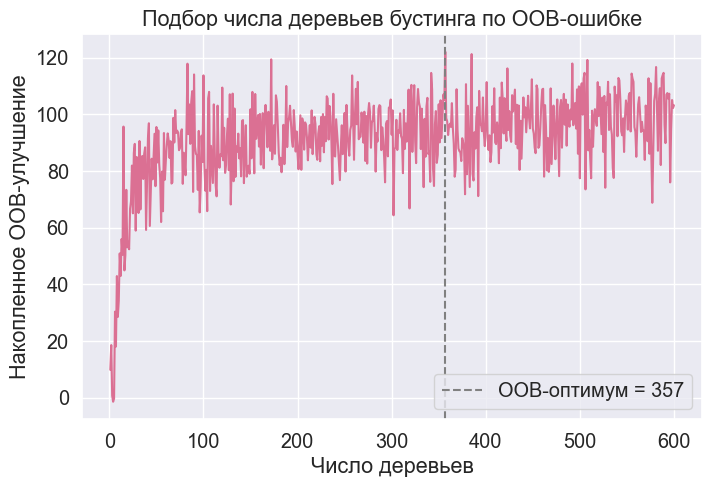

CV-тюнинг: лучшие параметры {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200}
OOB-тюнинг: оптимальное число деревьев 357


In [65]:
# Шаг 3. Сравнение вариантов на тесте и визуализация OOB-подбора
boost_table = pd.DataFrame([
    {
        'variant': 'default',
        'test_rmse': rmse(y_test_r, gb_test_pred),
        'test_mape': mape(y_test_r, gb_test_pred),
        'params': str(gb_gs.estimator.get_params()),
    },
    {
        'variant': 'CV-tuned',
        'test_rmse': rmse(y_test_r, gb_test_pred_tuned),
        'test_mape': mape(y_test_r, gb_test_pred_tuned),
        'params': str(gb_gs.best_params_),
    },
    {
        'variant': 'OOB-tuned',
        'test_rmse': rmse(y_test_r, y_stage_oob),
        'test_mape': mape(y_test_r, y_stage_oob),
        'params': f'n_estimators={best_n_oob}, learning_rate=0.05, max_depth=3, subsample=0.8',
    },
])

print('Градиентный бустинг: сравнение вариантов на тесте (RMSE и MAPE)')
display(boost_table[['variant', 'test_rmse', 'test_mape', 'params']])

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_improve) + 1), cum_improve, color='palevioletred')
plt.axvline(best_n_oob, ls='--', color='gray', label=f'OOB-оптимум = {best_n_oob}')
plt.xlabel('Число деревьев')
plt.ylabel('Накопленное OOB-улучшение')
plt.title('Подбор числа деревьев бустинга по OOB-ошибке')
plt.legend()
plt.show()

print(f'CV-тюнинг: лучшие параметры {gb_gs.best_params_}')
print(f'OOB-тюнинг: оптимальное число деревьев {best_n_oob}')

# Раздел 5. Эффекты воздействия



##5.1,5.2 ATE и LATE: определения

$$\text{ATE}=E\left[\text{Productivity}_{1i}-\text{Productivity}_{0i}\right]$$

$$\text{LATE}=E\left[\text{Productivity}_{1i}-\text{Productivity}_{0i}\mid \text{Deprivation}_{1i}>\text{Deprivation}_{0i}\right]$$

ATE — средний эффект недосыпа на продуктивность по всем работникам. LATE — эффект только для комплаенсеров: тех, у кого появление ребёнка до 3 лет действительно вызывает недосып ($\text{Deprivation}(Child{=}1)>\text{Deprivation}(Child{=}0)$). В нашем процессе истинный эффект отрицательный — недосып снижает продуктивность.

In [77]:

treatment = df['deprivation']   # Переменная, отвечающая за фактический свет

covariates = df.drop(columns=['deprivation','productivity'])

# Истинные потенциальные исходы (доступны только в симуляции)
Y1, Y0 = productivity1, productivity0
TE_true = Y1 - Y0
ATE_true = TE_true.mean()
compliers = (deprivation1 > deprivation0)
LATE_true = TE_true[compliers].mean()
CATE_true = g1 - g0
print(f"Истинный ATE = {ATE_true}")
print(f"Истинный LATE = {LATE_true}")


Истинный ATE = -14.81554815555341
Истинный LATE = -16.137726047004577


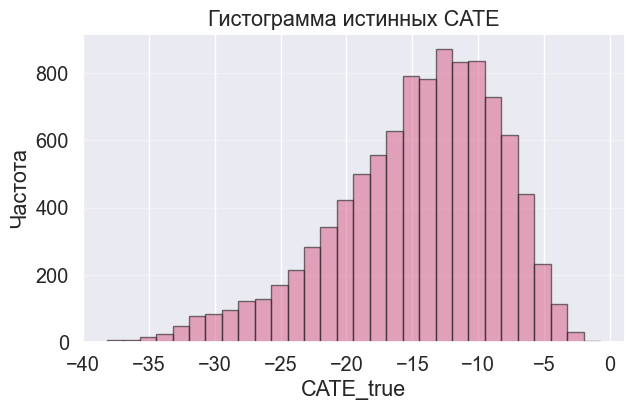

In [78]:

plt.figure(figsize=(7, 4))
plt.hist(CATE_true, bins=30, color = "palevioletred", edgecolor='k', alpha=0.6)
plt.title("Гистограмма истинных CATE")
plt.xlabel("CATE_true")
plt.ylabel("Частота")
plt.grid(axis='y', alpha=0.3)
plt.show()

##5.3 Наивная оценка по наблюдаемым значениям

In [106]:
ATE_naive = np.mean(productivity[deprivation == 1]) - np.mean(productivity[deprivation == 0])

# Сравнение точного приближения и наивной оценки
print(pd.DataFrame(data    = [ATE_true, ATE_naive],
                   index   = ['ATE', 'ATE naive'],
                   columns = ['Оценка']))

              Оценка
ATE       -14.815548
ATE naive  -7.219413


##5.4,5.5 Оценки ATE и CATE
Лучшей регрессионной моделью признана - Ridge
Лучшей классификационной - LogReg

Взвешивание на обратные вероятности

In [107]:

# Оценивание с помощью обратного взвешивания на вероятности IPW

# Подготовим данные
target   = df.loc[:, ['deprivation']]
features = df.loc[:, df.columns.drop(['productivity', 'deprivation', 'children'])]

# Подготовим метод машинного обучения
gb = LogisticRegression(C=0.05, penalty= 'l2', tol=1e-05)
gb.fit(features, target)

# Оценим условные вероятности P(educ = 1 | X)
prob_gb = gb.predict_proba(features)[:, 1]

# Оценим псевдоисходы
prod_pseudo = (productivity * deprivation) / prob_gb - (productivity * (1 - deprivation)) / (1 - prob_gb)

# Оценим ATE
ATE_IPW = np.mean(prod_pseudo)

МНК

In [108]:
import statsmodels.api as sm
y0  = df.loc[deprivation == 0, ['productivity']]
x0  = df.loc[deprivation == 0, df.columns.drop(['productivity', 'children', 'deprivation'])]
x0  = sm.add_constant(x0)
ls0 = sm.OLS(y0, x0).fit()

# МНК оценивание уравнения продуктивности для
# индивидов с депривацией
y1  = df.loc[deprivation == 1, ['productivity']]
x1  = df.loc[deprivation == 1, df.columns.drop(['productivity', 'children', 'deprivation'])]
x1  = sm.add_constant(x1)
ls1 = sm.OLS(y1, x1).fit()

# Оценим продуктивность при наличии и отсутствии депривации
# с помощью полученных МНК оценок
x = df.loc[:, df.columns.drop(['productivity', 'children', 'deprivation'])]
x = sm.add_constant(x)
  # МНК оценка E(wage0 | X) для всех индивидов
prod0_ls = ls0.predict(x)
  # МНК оценка E(wage1 | X) для всех индивидов
prod1_ls = ls1.predict(x)

# Оценки CATE
CATE_ls = np.array(prod1_ls - prod0_ls)
ATE_ls = np.mean(CATE_ls)

T-learner

In [109]:
# Оценивание ATE и CATE с помощью T-learner

# Подготовка модели: может быть и разной для тех кто с
# депривацией и без
rf = Ridge(alpha=10, tol=0.0001)
rf.fit(x0, y0)

# Оценки E(productivity | X, deprivation = 0) для всех индивидов,
# в том числе для тех, у кого (deprivation = 1).
prod0_rf = rf.predict(x)

# Обучение оценивать E(productivity | X, deprivation = 1)
rf.fit(x1, y1)

# Оценки E(productivity | X, deprivation = 1) для всех индивидов,
# в том числе для тех, у кого (deprivation = 0).
prod1_rf = rf.predict(x)

# Оценки CATE
CATE_T = prod1_rf - prod0_rf

S-learner (условные МО)

In [110]:
from copy import deepcopy
# Оценивание ATE и CATE с помощью S-learner

# Подготовим данные
y = df.loc[:, ['productivity']]
x = df.loc[:, df.columns.drop(['productivity', 'children'])]

# Подготовка модели: единая для тех у кого есть
# депривацией и для тех, у кого её нет
rf2 = Ridge(alpha=10, tol=0.0001)
rf2.fit(x, y)

# Оценки E(productivity | X, deprivation = 0) для всех индивидов,
# в том числе для тех, у кого (deprivation = 1).
x0s= deepcopy(x)
x0s["deprivation"] = 0
prod0_rf2  = rf2.predict(x0s)

# Оценки E(productivity | X, deprivation = 1) для всех индивидов,
# в том числе для тех, у кого (deprivation = 0).
x1s= deepcopy(x)
x1s["deprivation"] = 1
prod1_rf2  = rf2.predict(x1s)

# Оценки CATE
CATE_S = prod1_rf2 - prod0_rf2
ATE_S = np.mean(CATE_S)

Трансформация классов

In [111]:
# Оценим CATE методом трансформации классов

# Метод прогнозирования условных математических ожиданий оценок псевдоисходов
rf3 = Ridge(alpha=10, tol=0.0001)
rf3.fit(features, prod_pseudo)

# Оценки CATE (метод трансформации классов)
CATE_CT = rf3.predict(features)

X-learner

In [112]:

from econml.metalearners import XLearner
xl = XLearner(models=Ridge(alpha=10, tol=0.0001), propensity_model=LogisticRegression(C=0.05, penalty='l2', tol=1e-05))
xl.fit(df['productivity'], treatment, X=covariates)
CATE_X = xl.effect(covariates)


Метод с двойной устойчивостью

In [113]:
ATE_DR = np.mean((prod1_rf2 - prod0_rf2) + \
                 deprivation * (productivity - prod1_rf2) / prob_gb - \
                 (1 - deprivation) * (productivity - prod0_rf2) / (1 - prob_gb))

Двойное МО

In [114]:
# Данные в формате, необходимом для применения DML
dml_standard_data = dml.DoubleMLData(
                            data   = df,
                            y_col  = 'productivity',
                            d_cols = 'deprivation',
                            x_cols = ['training', 'coffein', 'experience'])

# Метод оценивания E(Y | X, T)
g_Y = Ridge(alpha=10, tol=0.0001)
# Метод оценивания E(T | X)
g_T = LogisticRegression(C=0.05, penalty='l2', tol=1e-05)

# Подготовка объекта
dml_standard = dml.DoubleMLIRM(obj_dml_data = dml_standard_data,
                               ml_g         = g_Y,
                               ml_m         = g_T,
                               n_rep        = 1,
                               n_folds      = 5)

# Оценим параметры
dml_standard.fit()

# Сохраним оценку
ATE_dml_standard = dml_standard.coef[0]

In [115]:
# Сопоставим результаты
print(pd.DataFrame(data    = [ATE_true, ATE_naive, ATE_ls, ATE_dml_standard, ATE_S, ATE_IPW, ATE_DR],
                   index   = ['ATE', 'ATE naive', 'ATE ls', 'ATE dml standard',
                              'ATE S-learner',
                              'ATE IPW', 'ATE DR'],
                   columns = ['Оценка']))

                     Оценка
ATE              -14.815548
ATE naive         -7.219413
ATE ls            -1.906421
ATE dml standard  -4.544592
ATE S-learner     -3.704503
ATE IPW            2.397781
ATE DR            -3.744112


In [116]:
CATE_mat = pd.DataFrame({'True': CATE_true, 'LS': CATE_ls, 'T-learner': CATE_T,
                         'S-learner': CATE_S, 'IPW': CATE_CT,'X-learner': CATE_X})
print(CATE_mat)

           True        LS  T-learner  S-learner        IPW  X-learner
0    -17.661111 -2.799089  -2.819974  -3.704503  -8.068379  -2.799239
1    -26.811111 -5.934211  -5.968607  -3.704503  -8.738659  -5.930382
2     -5.030357  6.327483  -6.514955  -3.704503  36.414169  -1.772418
3    -16.322222  3.197860  -9.665689  -3.704503  39.598896  -4.785175
4    -14.238889 -2.195288  -2.213571  -3.704503  -7.939288  -2.196204
...         ...       ...        ...        ...        ...        ...
9995 -12.772222 -3.728014  -3.752902  -3.704503  -8.266981  -3.726985
9996 -11.663333 -5.812596  -5.854092  -3.704503  -4.858828  -5.666910
9997  -5.672222 -4.564046  -4.592538  -3.704503  -8.445722  -4.561957
9998 -14.573333 -3.931523  -3.964912  -3.704503  -4.456660  -3.963142
9999 -25.880000 -1.748550  -1.772531  -3.704503  -3.989947  -1.782568

[10000 rows x 6 columns]


##5.6 LATE

ДМО без инструмента

In [90]:
g_Y_best = Ridge(alpha=10, tol=0.0001)
g_T_best = LogisticRegression(C=0.05, penalty='l2', tol=1e-05)

dml_no_iv_data = dml.DoubleMLData(
    data   = df,
    y_col  = 'productivity',
    d_cols = 'deprivation',
    x_cols = ['experience', 'coffein', 'training'])

dml_no_iv = dml.DoubleMLIRM(obj_dml_data = dml_no_iv_data,
                             ml_g         = g_Y_best,
                             ml_m         = g_T_best,
                             n_rep        = 1,
                             n_folds      = 5)

dml_no_iv.fit()


print("ДМО без ИП (смещённая оценка при эндогенности):")
print(dml_no_iv)

LATE_dml_no_iv = dml_no_iv.coef[0]

ДМО без ИП (смещённая оценка при эндогенности):
================== DoubleMLIRM Object ==================

------------------ Data Summary      ------------------
Outcome variable: productivity
Treatment variable(s): ['deprivation']
Covariates: ['experience', 'coffein', 'training']
Instrument variable(s): None
No. Observations: 10000


------------------ Score & Algorithm ------------------
Score function: ATE

------------------ Machine Learner   ------------------
Learner ml_g: Ridge(alpha=10)
Learner ml_m: LogisticRegression(C=0.05, tol=1e-05)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[17.91157454]]
Learner ml_g1 RMSE: [[15.69363278]]
Classification:
Learner ml_m Log Loss: [[0.46267264]]

------------------ Resampling        ------------------
No. folds: 5
No. repeated sample splits: 1

------------------ Fit Summary       ------------------
                 coef   std err          t         P>|t|     2.5 %    97.5 %
deprivation -4.541895  0.339886 -13.363007  9.946

ДМО с инструментом

In [91]:
g_Z_best = LogisticRegression(C=0.05, penalty='l2', tol=1e-05, max_iter=3000)


dml_iv_data = dml.DoubleMLData(
    data   = df,
    y_col  = 'productivity',
    d_cols = 'deprivation',
    z_cols = 'children',                               # инструмент
    x_cols = ['experience', 'coffein', 'training'])

dml_iv = dml.DoubleMLIIVM(obj_dml_data = dml_iv_data,
                           ml_g         = g_Y_best,
                           ml_m         = g_Z_best,
                           ml_r         = g_T_best,
                           n_rep        = 1,
                           n_folds      = 5)

dml_iv.fit()

print("ДМО с ИП (состоятельная оценка LATE):")
print(dml_iv)

LATE_dml_iv = dml_iv.coef[0]

ДМО с ИП (состоятельная оценка LATE):
================== DoubleMLIIVM Object ==================

------------------ Data Summary      ------------------
Outcome variable: productivity
Treatment variable(s): ['deprivation']
Covariates: ['experience', 'coffein', 'training']
Instrument variable(s): ['children']
No. Observations: 10000


------------------ Score & Algorithm ------------------
Score function: LATE

------------------ Machine Learner   ------------------
Learner ml_g: Ridge(alpha=10)
Learner ml_m: LogisticRegression(C=0.05, max_iter=3000, tol=1e-05)
Learner ml_r: LogisticRegression(C=0.05, tol=1e-05)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[17.65154783]]
Learner ml_g1 RMSE: [[16.26283756]]
Classification:
Learner ml_m Log Loss: [[0.46327835]]
Learner ml_r0 Log Loss: [[0.54335593]]
Learner ml_r1 Log Loss: [[0.3393111]]

------------------ Resampling        ------------------
No. folds: 5
No. repeated sample splits: 1

------------------ Fit Summary       -

In [92]:
print(pd.DataFrame(
    data    = [LATE_true, LATE_dml_no_iv, LATE_dml_iv],
    index   = [
                'LATE (истинный)',
                'LATE ДМО без ИП',
                'LATE ДМО с ИП'],
    columns = ['Оценка']
))

                    Оценка
LATE (истинный) -16.137726
LATE ДМО без ИП  -4.541895
LATE ДМО с ИП    -7.846810


##5.7 Худшие модели ATE,LATE


Обратное взвешивание на вероятности

In [93]:
# Оценивание с помощью обратного взвешивания на вероятности IPW

# Подготовим данные
target   = df.loc[:, ['deprivation']]
features = df.loc[:, df.columns.drop(['productivity', 'deprivation', 'children'])]

# Подготовим метод машинного обучения
gb_worst = KNeighborsClassifier(n_neighbors=11, p=1, weights='uniform')
gb_worst.fit(features, target)

# Оценим условные вероятности P(deprivation = 1 | X)
prob_gb_worst = gb_worst.predict_proba(features)[:, 1]

# KNN может выдавать вероятности ровно 0 или 1 — обрезаем во избежание деления на ноль
prob_gb_worst = np.clip(prob_gb_worst, 1e-6, 1 - 1e-6)

# Оценим псевдоисходы
prod_pseudo_worst = (productivity * deprivation) / prob_gb_worst - (productivity * (1 - deprivation)) / (1 - prob_gb_worst)

# Оценим ATE
ATE_IPW_worst = np.mean(prod_pseudo_worst)

МНК

In [94]:
# МНК не использует ML-модели — оценка совпадает с 5.4
y0_w = df.loc[deprivation == 0, ['productivity']]
x0_w = df.loc[deprivation == 0, df.columns.drop(['productivity', 'children', 'deprivation'])]
x0_w = sm.add_constant(x0_w)
ls0_w = sm.OLS(y0_w, x0_w).fit()

y1_w = df.loc[deprivation == 1, ['productivity']]
x1_w = df.loc[deprivation == 1, df.columns.drop(['productivity', 'children', 'deprivation'])]
x1_w = sm.add_constant(x1_w)
ls1_w = sm.OLS(y1_w, x1_w).fit()

x_w = df.loc[:, df.columns.drop(['productivity', 'children', 'deprivation'])]
x_w = sm.add_constant(x_w)
prod0_ls_w = ls0_w.predict(x_w)
prod1_ls_w = ls1_w.predict(x_w)

CATE_ls_worst = np.array(prod1_ls_w - prod0_ls_w)
ATE_ls_worst  = np.mean(CATE_ls_worst)

S-learner (условное МО)

In [95]:

# Оценивание ATE и CATE с помощью S-learner

# Подготовим данные
y_s  = df.loc[:, 'productivity']
x_s  = df.loc[:, df.columns.drop(['productivity', 'children'])]

# Подготовка модели: единая для тех у кого есть
# депривация и для тех, у кого её нет
rf2_worst = KNeighborsRegressor(n_neighbors=51, p=1, weights='uniform')
rf2_worst.fit(x_s, y_s)

# Оценки E(productivity | X, deprivation = 0) для всех индивидов,
# в том числе для тех, у кого (deprivation = 1).
x0s_w = deepcopy(x_s)
x0s_w["deprivation"] = 0
prod0_rf2_worst = rf2_worst.predict(x0s_w)

# Оценки E(productivity | X, deprivation = 1) для всех индивидов,
# в том числе для тех, у кого (deprivation = 0).
x1s_w = deepcopy(x_s)
x1s_w["deprivation"] = 1
prod1_rf2_worst = rf2_worst.predict(x1s_w)

# Оценки CATE
CATE_S_worst = prod1_rf2_worst - prod0_rf2_worst
ATE_S_worst  = np.mean(CATE_S_worst)

Метод с двойной устойчивостью

In [96]:
ATE_DR_worst = np.mean(
    (prod1_rf2_worst - prod0_rf2_worst)
    + deprivation * (productivity - prod1_rf2_worst) / prob_gb_worst
    - (1 - deprivation) * (productivity - prod0_rf2_worst) / (1 - prob_gb_worst)
)

Двойное МО

In [97]:
# Данные в формате, необходимом для применения DML
dml_standard_data = dml.DoubleMLData(
                            data   = df,
                            y_col  = 'productivity',
                            d_cols = 'deprivation',
                            x_cols = ['training', 'coffein', 'experience','children'])

# Метод оценивания E(Y | X, T)
g_Y_worst = KNeighborsRegressor(n_neighbors=51, p=1, weights='uniform')
# Метод оценивания E(T | X)
g_T_worst = KNeighborsClassifier(n_neighbors=11, p=1, weights='uniform')

# Подготовка объекта
dml_standard = dml.DoubleMLIRM(obj_dml_data = dml_standard_data,
                               ml_g         = g_Y_worst,
                               ml_m         = g_T_worst,
                               n_rep        = 1,
                               n_folds      = 5)

# Оценим параметры
dml_standard.fit()

# Сохраним оценку
ATE_dml_standard_worst = dml_standard.coef[0]

In [98]:
# Сопоставим результаты ATE: лучшие vs худшие модели
print(pd.DataFrame(
    data    = [ATE_true,
               ATE_ls,           ATE_ls_worst,
               ATE_dml_standard, ATE_dml_standard_worst,
               ATE_S,            ATE_S_worst,
               ATE_IPW,          ATE_IPW_worst,
               ATE_DR,           ATE_DR_worst],
    index   = ['ATE (истинный)',
                'ATE ls           (Ridge)',  'ATE ls           (KNN)',
                'ATE dml standard (Ridge)',  'ATE dml standard (KNN)',
                'ATE S-learner    (Ridge)',  'ATE S-learner    (KNN)',
                'ATE IPW          (LogReg)', 'ATE IPW          (KNN)',
                'ATE DR           (Ridge)',  'ATE DR           (KNN)'],
    columns = ['Оценка']
))

                                  Оценка
ATE (истинный)                -14.815548
ATE ls           (Ridge)       -1.906421
ATE ls           (KNN)         -1.906421
ATE dml standard (Ridge)       -4.416511
ATE dml standard (KNN)         -5.047013
ATE S-learner    (Ridge)       -3.704503
ATE S-learner    (KNN)         -4.037831
ATE IPW          (LogReg)       2.397781
ATE IPW          (KNN)     182830.334550
ATE DR           (Ridge)       -3.744112
ATE DR           (KNN)      -8437.150512


LATE

ДМО без инструмента

In [99]:
dml_no_iv_worst_data = dml.DoubleMLData(
    data   = df,
    y_col  = 'productivity',
    d_cols = 'deprivation',
    x_cols = ['experience', 'coffein', 'training'])

dml_no_iv_worst = dml.DoubleMLIRM(obj_dml_data = dml_no_iv_worst_data,
                                   ml_g         = KNeighborsRegressor(n_neighbors=51, p=1, weights='uniform'),
                                   ml_m         = KNeighborsClassifier(n_neighbors=11, p=1, weights='uniform'),
                                   n_rep        = 1,
                                   n_folds      = 5)

dml_no_iv_worst.fit()
LATE_dml_no_iv_worst = dml_no_iv_worst.coef[0]

print("ДМО без ИП (KNN-модели):")
print(dml_no_iv_worst)

ДМО без ИП (KNN-модели):
================== DoubleMLIRM Object ==================

------------------ Data Summary      ------------------
Outcome variable: productivity
Treatment variable(s): ['deprivation']
Covariates: ['experience', 'coffein', 'training']
Instrument variable(s): None
No. Observations: 10000


------------------ Score & Algorithm ------------------
Score function: ATE

------------------ Machine Learner   ------------------
Learner ml_g: KNeighborsRegressor(n_neighbors=51, p=1)
Learner ml_m: KNeighborsClassifier(n_neighbors=11, p=1)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[18.1250527]]
Learner ml_g1 RMSE: [[15.78703905]]
Classification:
Learner ml_m Log Loss: [[0.50989743]]

------------------ Resampling        ------------------
No. folds: 5
No. repeated sample splits: 1

------------------ Fit Summary       ------------------
                 coef   std err         t   P>|t|     2.5 %    97.5 %
deprivation -5.675551  1.674402 -3.389599  0.0007 -

ДМО с инструментом

In [100]:
dml_iv_worst_data = dml.DoubleMLData(
    data   = df,
    y_col  = 'productivity',
    d_cols = 'deprivation',
    z_cols = 'children',
    x_cols = ['experience', 'coffein', 'training'])

dml_iv_worst = dml.DoubleMLIIVM(obj_dml_data = dml_iv_worst_data,
                                 ml_g         = KNeighborsRegressor(n_neighbors=51, p=1, weights='uniform'),
                                 ml_m         = KNeighborsClassifier(n_neighbors=11, p=1, weights='uniform'),
                                 ml_r         = KNeighborsClassifier(n_neighbors=11, p=1, weights='uniform'),
                                 n_rep        = 1,
                                 n_folds      = 5)

dml_iv_worst.fit()
LATE_dml_iv_worst = dml_iv_worst.coef[0]

print("ДМО с ИП (KNN-модели):")
print(dml_iv_worst)

ДМО с ИП (KNN-модели):
================== DoubleMLIIVM Object ==================

------------------ Data Summary      ------------------
Outcome variable: productivity
Treatment variable(s): ['deprivation']
Covariates: ['experience', 'coffein', 'training']
Instrument variable(s): ['children']
No. Observations: 10000


------------------ Score & Algorithm ------------------
Score function: LATE

------------------ Machine Learner   ------------------
Learner ml_g: KNeighborsRegressor(n_neighbors=51, p=1)
Learner ml_m: KNeighborsClassifier(n_neighbors=11, p=1)
Learner ml_r: KNeighborsClassifier(n_neighbors=11, p=1)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[17.91434055]]
Learner ml_g1 RMSE: [[16.38397537]]
Classification:
Learner ml_m Log Loss: [[0.50994]]
Learner ml_r0 Log Loss: [[1.02899235]]
Learner ml_r1 Log Loss: [[0.40922494]]

------------------ Resampling        ------------------
No. folds: 5
No. repeated sample splits: 1

------------------ Fit Summary       

In [101]:
# Сопоставим результаты LATE: лучшие vs худшие модели
print(pd.DataFrame(
    data    = [ATE_true,          LATE_true,
               LATE_dml_no_iv,    LATE_dml_iv,
               LATE_dml_no_iv_worst, LATE_dml_iv_worst],
    index   = ['ATE  (истинный)',
                'LATE (истинный)',
                'LATE ДМО без ИП  (Ridge + LogReg)',
                'LATE ДМО с ИП   (Ridge + LogReg)',
                'LATE ДМО без ИП  (KNN + KNN)',
                'LATE ДМО с ИП   (KNN + KNN)'],
    columns = ['Оценка']
))

                                      Оценка
ATE  (истинный)                   -14.815548
LATE (истинный)                   -16.137726
LATE ДМО без ИП  (Ridge + LogReg)  -4.541895
LATE ДМО с ИП   (Ridge + LogReg)   -7.846810
LATE ДМО без ИП  (KNN + KNN)       -5.675551
LATE ДМО с ИП   (KNN + KNN)        -4.189036
